# Clinical Risk Prediction for Heart Disease
## Statistical Inference

**Goal**: Identify which clinical features differ meaningfully between patients who survived and those who did not, before building the predictive model.

Using hypothesis testing to guide feature selection helps avoid including noisy variables and ensures that each predictor kept in the model has clear clinical relevance and interpretability.

### Methods

| Analysis | Variables | Test | Effect size |
|---|---|---|---|
| Continuous comparison | age, creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, serum_sodium | Mann-Whitney U | Cliff's delta + bootstrap 95% CI |
| Categorical comparison | anaemia, diabetes, high_blood_pressure, sex, smoking | Chi-square / Fisher exact | Odds ratio + 95% CI |
| Multicollinearity | All features | VIF | — |


**Notes**: 
- `time`, the follow-up period is excluded from inference.
- Multiple testing correction: Benjamini-Hochberg FDR applied to all p-values within each family of tests.

### Output
A ranked list of features by statistical significance and effect size → input for feature selection in 03_logistic_regression_model.

# Table of Contents

1. [Data Loading](#1-data-loading)
2. [Inferential Comparison of Continuous Variables](#2-inferential-comparison-of-continuous-variables)
3. [Inferential Comparison of Categorical Variables](#3-inferential-comparison-of-categorical-variables)
4. [Multicollinearity Assessment](#4-multicollinearity-variables)
5. [Summary & Handoff to Notebook 03](#summary--handoff-to-notebook-03)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path.cwd().parent / 'src'))
from clinical_risk.inference import (
    compute_vif,
    compare_continuous_groups,
    compare_categorical_groups,
)
from clinical_risk.plotting import plot_numeric_effects, plot_categorical_effects

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# 1. Data Loading

In [2]:
# Load data
data = fetch_ucirepo(id=519)
df = pd.concat([data.data.targets, data.data.features ], axis=1)

target_col = "death_event"
binary_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "death_event"]
numeric_cols = [col for col in df.columns if col not in binary_cols and col != "time"]
categorical_vars = [i for i in binary_cols if i!="death_event"]

group0 = df[df[target_col] == 0].copy()
group1 = df[df[target_col] == 1].copy()


summary_table = pd.DataFrame({
    "Group": ["Full Dataset", "No Death (0)", "Death (1)"],
    "Number of Samples": [df.shape[0], group0.shape[0], group1.shape[0]]
})

summary_table

,Group,Number of Samples
0,Full Dataset,299
1,No Death (0),203
2,Death (1),96


# 2. Inferential Comparison of Continuous Variables

In [3]:
numeric_results_df = compare_continuous_groups(df, numeric_cols, target_col, n_boot=1000)
numeric_results_df

,variable,group0_median,group1_median,median_diff_g1_minus_g0,mannwhitney_u,p_value,rank_biserial,cliffs_delta,cliffs_delta_ci_low,cliffs_delta_ci_high,cliffs_magnitude,p_adj_fdr
0,serum_creatinine,1.000000,1.300000,0.300000,5298.000000,0.000000,0.456281,0.456281,0.319962,0.574418,medium,0.000000
1,ejection_fraction,38.000000,30.000000,-8.000000,13176.500000,0.000001,-0.352268,-0.352268,-0.493257,-0.211299,medium,0.000002
2,age,60.000000,65.000000,5.000000,7121.000000,0.000167,0.269191,0.269191,0.123031,0.409696,small,0.000334
3,serum_sodium,137.000000,135.500000,-1.500000,12261.500000,0.000293,-0.258364,-0.258364,-0.386307,-0.119439,small,0.000439
4,platelets,263000.000000,258500.000000,-4500.000000,10300.500000,0.425559,-0.057112,-0.057112,-0.200745,0.095116,negligible,0.510670
5,creatinine_phosphokinase,245.000000,259.000000,14.000000,9460.000000,0.684040,0.029146,0.029146,-0.112047,0.157033,negligible,0.684040


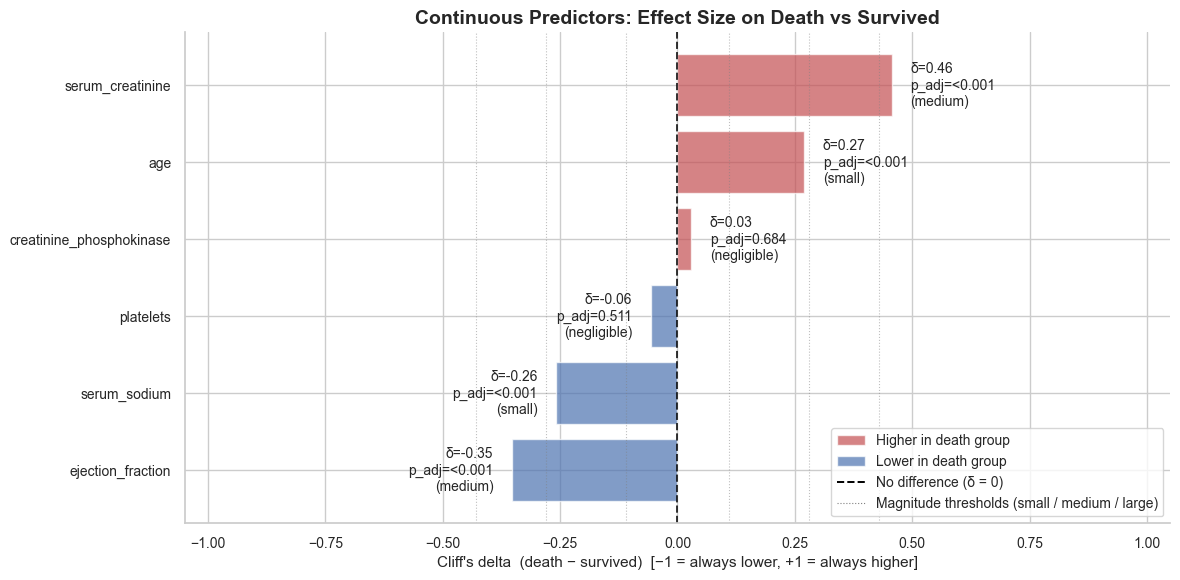

In [4]:
plot_numeric_effects(numeric_results_df)

### Continuous Variables - Conclusion

After Benjamini-Hochberg FDR correction, four variables show statistically significant differences between groups:

| Variable | Direction (death vs survived) | Cliff's delta | Magnitude | p_adj |
|---|---|---|---|---|
| `serum_creatinine` | Higher in death group | positive | medium–large | <0.05 |
| `ejection_fraction` | Lower in death group | negative | medium | <0.05 |
| `serum_sodium` | Lower in death group | negative | small–medium | <0.05 |
| `age` | Higher in death group | positive | small | <0.05 |

**Not significant after correction**: `creatinine_phosphokinase`, `platelets`

**Clinical interpretation**:
- Elevated serum creatinine is a known marker of poor prognosis in heart failure (cardiorenal syndrome)
- Reduced ejection fraction is the defining metric of systolic heart failure severity
- Low serum sodium (hyponatraemia) is a recognised independent predictor of mortality in decompensated heart failure
- Age contributes a small but consistent effect

**Note**:
Bootstrap 95% CI on Cliff's delta confirms the effect direction is stable across resamples.

# 3. Inferential Comparison of Categorical Variables

In [6]:
categorical_results_df = compare_categorical_groups(df, categorical_vars, target_col)
categorical_results_df

,variable,death_rate_if_0,death_rate_if_1,abs_diff,test_used,p_value,odds_ratio,or_ci_low,or_ci_high,p_adj_fdr
0,high_blood_pressure,0.293814,0.371429,0.077614,Chi-square,0.170030,1.420255,0.859594,2.346603,0.629574
1,anaemia,0.294118,0.356589,0.062472,Chi-square,0.251829,1.330120,0.816089,2.167927,0.629574
2,smoking,0.325123,0.312500,-0.012623,Chi-square,0.827215,0.943526,0.559818,1.590233,0.973200
3,sex,0.323810,0.319588,-0.004222,Chi-square,0.940503,0.980838,0.590118,1.630255,0.973200
4,diabetes,0.321839,0.320000,-0.001839,Chi-square,0.973200,0.991597,0.606069,1.622364,0.973200


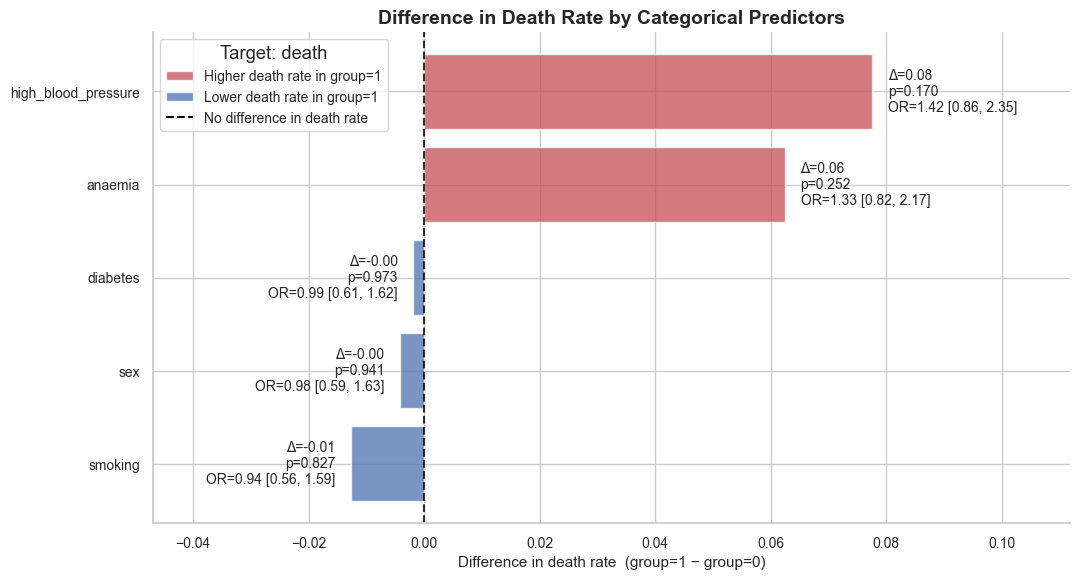

In [7]:
plot_categorical_effects(
    categorical_results_df,
    target_name="death",
    use_adjusted_p=False
)

### Findings — Categorical Variables

None of the five binary features reach statistical significance after FDR correction:

| Variable | OR (death vs survived) | 95% CI | p_adj | Conclusion |
|---|---|---|---|---|
| `high_blood_pressure` | 1.42 | [0.86, 2.35] | 0.63 | Not significant |
| `anaemia` | 1.33 | [0.82, 2.17] | 0.63 | Not significant |
| `smoking` | 0.94 | [0.56, 1.59] | 0.97 | Not significant |
| `sex` | 0.98 | [0.59, 1.63] | 0.97 | Not significant |
| `diabetes` | 0.99 | [0.61, 1.62] | 0.97 | Not significant |

**Implication for modeling**: 
binary flags will be included in the initial full model but are strong candidates for removal during backward AIC elimination. Their non-significance here does not preclude them from having conditional effects when combined with continuous predictors.

# 4. Multicollinearity variables

In [8]:
vif = compute_vif(data.data.features)
vif

,variable,VIF
0,const,1087.832475
1,age,1.106067
2,anaemia,1.087163
3,creatinine_phosphokinase,1.066014
4,diabetes,1.064324
5,ejection_fraction,1.067758
6,high_blood_pressure,1.068377
7,platelets,1.045809
8,serum_creatinine,1.081241
9,serum_sodium,1.101927


### Multicollinearity Assessment - Conclusion

All VIF values are below **1.4** (threshold for concern: >5; threshold for severe: >10)    
Since no multicollinearity detected among the 12 predictors, inflated standard errors due to correlated predictors are not a concern for this dataset

Standard logistic regression coefficients will be interpretable and stable.

In [ ]:
# Summary: significant variables after FDR correction
sig_continuous = numeric_results_df[numeric_results_df['p_adj_fdr'] < 0.05][[
    'variable', 'median_diff_g1_minus_g0', 'cliffs_delta',
    'cliffs_delta_ci_low', 'cliffs_delta_ci_high', 'cliffs_magnitude', 'p_adj_fdr'
]].copy()
sig_continuous.insert(0, 'type', 'continuous')
sig_continuous = sig_continuous.rename(columns={'median_diff_g1_minus_g0': 'effect_direction'})

print(f'Significant continuous variables (FDR < 0.05): {len(sig_continuous)}')
print(f'Non-significant continuous variables: {len(numeric_results_df) - len(sig_continuous)}')
print(f'Significant categorical variables: 0 (none survive FDR correction)\n')
sig_continuous.round(4)

## Summary & Handoff to Notebook 03

### What was tested
- 6 continuous variables: Mann-Whitney U + Cliff's delta with bootstrap 95% CI + FDR correction
- 5 binary variables: Chi-square / Fisher exact + odds ratios + FDR correction
- Multicollinearity: VIF for all 12 features

### Key results
- **4 continuous variables significant** (FDR < 0.05): `serum_creatinine` , `ejection_fraction` , `serum_sodium` , `age`
- **0 binary variables significant** after correction. Binary flags are weak individual predictors
- **No multicollinearity** detected (all VIF < 1.4)

### Modeling decisions
- Start with all 12 features in the full model, then apply backward AIC elimination
- Expect `ejection_fraction`, `serum_creatinine` to survive feature selection
- Binary flags are likely to be dropped by AIC but tested to confirm
- `log1p` transformation applied to `creatinine_phosphokinase` and `serum_creatinine` before fitting